In [ ]:
# Install required packages
!pip install --upgrade --quiet playwright
!pip install --upgrade --quiet beautifulsoup4
!pip install --upgrade --quiet lxml
!pip install --upgrade --quiet html5lib
!pip install --upgrade --quiet pandas
!pip install --upgrade --quiet nest_asyncio

print('✓ Packages installed!')

**Slides:** [browser-automation.pdf](./browser-automation.pdf)

In this example we are going to scrape the [OpenSyllabus works page](https://analytics.opensyllabus.org/record/works) for books included on college syllabi.

Traditionally Python programmers use [BeautifulSoup](https://beautiful-soup-4.readthedocs.io/en/latest/) to scrape content from the interent. Instead of being *traditional*, we're going to use [Playwright](https://playwright.dev/python/), a **browser automation tool**! This means you actually control the browser! Filling out forms, clicking buttons, downloading documents... it's magic!!!✨✨✨

# OpenSyllabus works list

## What we'll learn/use

- Selectors
- 'Show more' button pagination
- Creating and saving a dataframe

## Installation

We need to install a few tools first! Remove the `#` and run the cell to install the Python packages and browsers that we'll need for our scraping adventure.

In [1]:
# %pip install --quiet lxml html5lib beautifulsoup4 pandas
# %pip install --quiet playwright
# !playwright install-deps
# !playwright install chromium firefox

We'll also set it up so that Playwright works well in Windows on a Jupyter notebook.

In [6]:
# Detect if we're running in Google Colab
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

import platform
import asyncio
import nest_asyncio

if platform.system() == "Windows":
    asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

try:
    asyncio.get_running_loop()
    nest_asyncio.apply()
except RuntimeError:
    pass

## Requests + BS4 = doesn't work

First, let's see what it looks like when we're scraping a "normal" site. You grab the page, you tell BeautifulSoup what you want, you get it.

In [7]:
import requests
from bs4 import BeautifulSoup

response = requests.get("https://bbc.com")
doc = BeautifulSoup(response.text)
headlines = doc.find_all('h2')
headlines[:5]

[<h2 class="sc-feaf8701-3 efpPCS" data-testid="card-headline">Trump vows to hit Iran 'very hard' as Iranian president apologises to Gulf nations for attacks</h2>,
 <h2 class="sc-feaf8701-3 eQumHa" data-testid="card-headline">This iceberg was once the biggest in the world. Now it has just weeks left</h2>,
 <h2 class="sc-feaf8701-3 eQumHa" data-testid="card-headline">Armed robots take to the battlefield in Ukraine war</h2>,
 <h2 class="sc-feaf8701-3 eQumHa" data-testid="card-headline">Withheld Epstein files with accusations against Trump released by justice department</h2>,
 <h2 class="sc-feaf8701-3 eQumHa" data-testid="card-headline">Canada's PM calls for Andrew to be removed from line of succession</h2>]

But now let's try it with a site that does *not* work with this "normal" approach to scraping. We'll be using the [OpenSyllabus works page](https://analytics.opensyllabus.org/record/works).

In [8]:
import requests
from bs4 import BeautifulSoup

response = requests.get("https://schedules.ire.org/nicar-2026/#/schedule")
doc = BeautifulSoup(response.text)

No errors yet, but let's try to find some book titles... 

In [9]:
doc.find_all(class_='text-lg')

[]

No luck! But maybe our `class_=` magic is wrong? Who even knows how that works? We can use `doc.text` to look at alllllllll of the text on the page.

In [10]:
print(doc.text)





NICAR 2026 schedule | March 4-7, 2026 | Indianapolis





















Skip
        to main content





                    Conference Home
                







Schedule
Speakers
Sponsors
Exhibitors
At the hotel






Schedule
Speakers
Sponsors
Exhibitors
At the hotel










Not seeing the latest data? Try a hard refresh (Cmd/Ctrl + Shift + R).
















Loading...















Looks like **the content isn't even on the page**. Now we can move on to *Playwright!*

## Opening up the browser and visiting our destination

In the example below, we can choose a setting for `headless`.

- `headless=True` means "hide the browser"
- `headless=False` means "show the browser"

In [16]:
from playwright.async_api import async_playwright

# "Hey, open up a browser"
playwright = await async_playwright().start()

# Colab can't open a visible browser, so we run headless there
if IN_COLAB:
    use_headless = True
else:
    use_headless = False

browser = await playwright.chromium.launch(headless=use_headless)

# Create a new browser window
page = await browser.new_page()

In [17]:
await page.goto("https://schedules.ire.org/nicar-2026/#/schedule")

<Response url='https://schedules.ire.org/nicar-2026/' request=<Request url='https://schedules.ire.org/nicar-2026/' method='GET'>>

If you run headless, you often want to take a screenshot to confirm what's going on in your scraping world. **I usually recommend using `headless=False` until you confirm your scraper works,** then change it to headless mode so it doesn't get in the way.

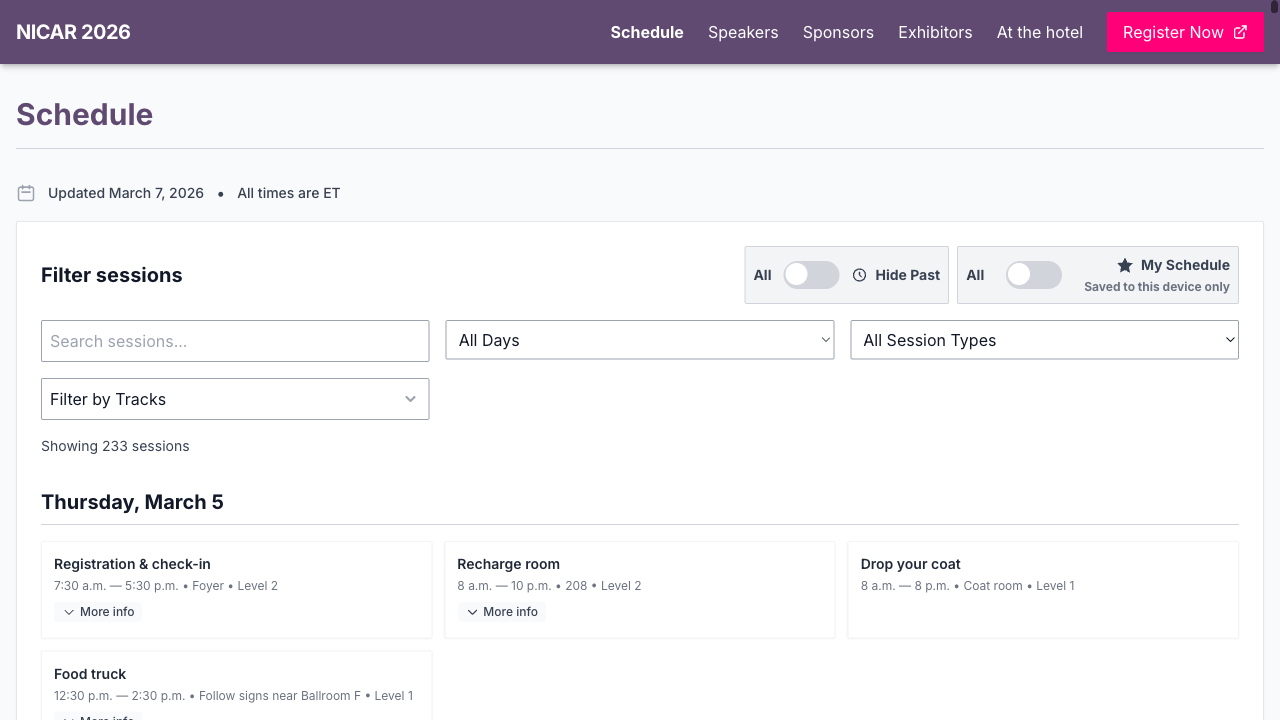

In [18]:
from IPython.display import Image

Image(await page.screenshot())

## Grab the content from the page

Now we need to get the *content* from the page. Everyone loves using BeautifulSoup to scrape, so why don't we just do that? You use `await page.content()` to save the contents of the page and feed it directly to BeautifulSoup.

In [28]:
from bs4 import BeautifulSoup

html = await page.content()
doc = BeautifulSoup(html)

Once you push the HTML from the Playwright page into BeautifulSoup, you can use all the same selectors and filters that you can in your "normal" scraping world.

In [27]:
titles = doc.find_all(class_='block group flex-1')
for title in titles[:10]:
    print(title.text)
    print(title['href'])



Welcome to NICAR! First-timers welcome and networking event 👋


#/session/1311


AI tools for journalists


#/session/1302


Catching the quiet changes: Automating website monitoring for investigative journalism with Visualping


#/session/1348


Data journalism for new reporters


#/session/1193


Excel 1: Getting started with spreadsheets (PC lab)


#/session/1306


Following the money in college sports’ new era


#/session/1286


Google Sheets 1: Getting started with spreadsheets


#/session/1256


How to get data out of complex documents using AI


#/session/1002


Introduction to the command line (OSX)


#/session/1254


PyCAR


#/session/1310


## Developing your selectors

Let's be honest: **writing custom scraping code isn't anyone's favorite thing to do.**

To put together your selectors to grab the "right" data, I suggest using [my ChatGPT prompt](https://chatgpt.com/share/69a2f31d-727c-800d-b3ca-65a32a714336) to help. You can see the [original prompt here](https://gist.github.com/jsoma/d46ba769764866331a83d702a3054751) if you'd like to use it with another AI tool.

You want to right-click the data you're interested in, then select **Inspect**. That provides two approaches to finding your region of interest: either browsing around on the right-hand side...

<img src="finding-row-1.gif" style="max-width: 600px">

...or using the element selector and clicking on the left-hand side.

<img src="finding-row-2.gif" style="max-width: 600px">

[Pandas](https://pandas.pydata.org/) is the Python equivalent to Excel, and it's great at dealing with tabular data! If you can build a list of dictionaries it's fantastic for saving the content.

In [ ]:
import pandas as pd

rows = []
for tr in doc.select("tr.sc-9d100f21-6"):
    row = {}

    try:
        row["rank"] = tr.select_one("p.sc-9d100f21-7").get_text(strip=True)
    except:
        pass

    try:
        row["title"] = tr.select_one("a[href^='/singleton/works'] p").get_text(strip=True)
    except:
        pass

    try:
        row["author"] = tr.select_one("a[href^='/singleton/authors'] p").get_text(strip=True)
    except:
        pass

    try:
        row["score"] = tr.select_one("div[name='score-star'] + p").get_text(strip=True)
    except:
        pass

    try:
        row["appearances"] = tr.select_one("div.elzFcv").get_text(strip=True)
    except:
        pass

    rows.append(row)

df = pd.DataFrame(rows)
df.head(10)

We clicked and clicked and clicked. How far down the list did we get? 

In [ ]:
df.tail(10)

## Saving the file

Now we can save our pandas dataframe to a CSV to open up in Excel or wherever else!

In [ ]:
df.to_csv("books.csv", index=False)